# Marine Animal Data Analysis and Ship Collision Prediction

This project analyzes marine animal data using the [pyOBIS](https://github.com/iobis/pyobis) API and predicts potential collisions with ships data. By integrating these datasets, we aim to better understand marine animal distributions and identify high-risk areas for ship collisions.

## Objectives

1. **Data Retrieval and Analysis**:
   - Use the pyOBIS API to retrieve occurrence data for marine mammals. Analyze patterns in marine animal distribution. Visuzlize species occurence data.

2. **Collision Risk Assessment**:
   - Predict potential collision hotspots by overlaying marine animal distributions with shipping routes
   - Calculate risk scores based on proximity, species density, and seasonal factors

3. **Visualization and Reporting**:
   - Create plot maps highlighting high-risk areas.

## Methodology

### Data Collection
- Marine mammal occurrence data from OBIS for 15 key species
- Vessel route data with timestamp, geolocation, and course information
- IMMA spatial data on critical marine mammal habitats (TODO)

### Analysis Techniques
- Spatial analysis using distance calculations and clustering algorithms (DBSCAN)
- Risk assessment based on:
  - Distance factor: Proximity of vessels to marine mammals
  - Species density: Number of different species in an area
  - Seasonal patterns: Monthly variations in marine mammal activity
  - Geographic hotspots: Areas with high concentration of occurrences

### Risk Calculation Model
```
Risk Score = 100 * (0.6 * Distance Factor + 0.3 * Species Count Factor + 0.1 * Seasonal Factor)    // factor weights are taken based on assumptions (can be changed)
```
Risk Categories:
- Low: 0-25
- Moderate: 26-50
- High: 51-75
- Very High: 76-100

## Main Tools
- **[pyOBIS](https://github.com/iobis/pyobis)**: Python client for accessing the Ocean Biogeographic Information System API
- **[IMMA e-Atlas](https://www.marinemammalhabitat.org/imma-eatlas/)**: Global atlas of Important Marine Mammal Areas


## Data Sources

- **OBIS (Ocean Biogeographic Information System)**
- **IMMA (Important Marine Mammal Areas)**
- **Sample vessel route data**: Simulated

## References and Resources

- [pyOBIS Documentation](https://pyobis.readthedocs.io/)
- [IMMA e-Atlas](https://www.marinemammalhabitat.org/imma-eatlas/)


In [92]:

import urllib.request

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
import folium
from folium.plugins import HeatMap
from sklearn.cluster import DBSCAN
from matplotlib.patches import Rectangle


from pyobis import taxa, occurrences, dataset, nodes, checklist



In [93]:
# Tests for taxa
from pyobis import taxa

query = taxa.search(scientificname="Mola mola")
query.execute()
query.data  # Returns the data
query.api_url  # Returns the API URL

# Testing the taxa search and taxon retrieval
data = taxa.search(scientificname="Mola mola").execute()
print(data)
taxa.taxon(10332)
taxa.taxon(127405)

{'total': 1, 'results': [{'scientificName': 'Mola mola', 'scientificNameAuthorship': '(Linnaeus, 1758)', 'taxonID': 127405, 'bold_id': 29489, 'ncbi_id': 94237, 'taxonRank': 'Species', 'taxonomicStatus': 'accepted', 'acceptedNameUsage': 'Mola mola', 'acceptedNameUsageID': 127405, 'is_marine': True, 'is_brackish': False, 'is_freshwater': False, 'is_terrestrial': False, 'kingdom': 'Animalia', 'phylum': 'Chordata', 'subphylum': 'Vertebrata', 'infraphylum': 'Gnathostomata', 'superclass': 'Actinopteri', 'class': 'Teleostei', 'order': 'Tetraodontiformes', 'family': 'Molidae', 'genus': 'Mola', 'species': 'Mola mola', 'kingdomid': 2, 'phylumid': 1821, 'subphylumid': 146419, 'infraphylumid': 1828, 'superclassid': 843664, 'classid': 293496, 'orderid': 10332, 'familyid': 125609, 'genusid': 126233, 'speciesid': 127405, 'category': 'VU'}]}


In [94]:
# Tests for occurrences
from pyobis import occurrences

query = occurrences.search(scientificname="Mola mola")
query.execute()
query.data  # Returns the data
query.api_url  # Returns the OBIS API URL
query.mapper_url  # Returns the OBIS Mapper URL

data = occurrences.search(scientificname="Mola mola", size=10).execute()
occurrences.search(
    geometry="POLYGON((30.1 10.1, 10 20, 20 40, 40 40, 30.1 10.1))", size=20
)

2025-04-02 23:43:33 - pyobis.obisutils - INFO - 22929 to be fetched. Estimated time =1.8151370358467103209 seconds
2025-04-02 23:43:33 - pyobis.obisutils - INFO - Fetching: [███████████████████████████████████████████.........................................................] 10000/22929
2025-04-02 23:43:58 - pyobis.obisutils - INFO - Fetching: [███████████████████████████████████████████████████████████████████████████████████████.............] 20000/22929
2025-04-02 23:44:10 - pyobis.obisutils - INFO - Fetching: [████████████████████████████████████████████████████████████████████████████████████████████████████] 22929/22929
2025-04-02 23:44:15 - pyobis.obisutils - INFO - Fetched 22929 records.
2025-04-02 23:44:19 - pyobis.obisutils - INFO - 10 to be fetched. Estimated time =1.22895513296127310 seconds
2025-04-02 23:44:19 - pyobis.obisutils - INFO - Fetching: [████████████████████████████████████████████████████████████████████████████████████████████████████] 10/10
2025-04-02 23:44:2

In [95]:
print(data)

                                associatedReferences      basisOfRecord                              bibliographicCitation  brackish catalogNumber      class  classid collectionCode      coordinatePrecision  coordinateUncertaintyInMeters                               datasetID                                        datasetName       dateIdentified      date_end      date_mid    date_start  date_year  decimalLatitude  decimalLongitude              eventDate  eventTime   family  familyid               footprintWKT genus  genusid    geodeticDatum    georeferencedDate       gigaclass  gigaclassid                identificationRemarks individualCount    infraphylum  infraphylumid             institutionCode   kingdom  kingdomid                                         license  marine             modified nomenclaturalCode                             occurrenceID occurrenceRemarks occurrenceStatus              order  orderid        ownerInstitutionCode    parvphylum  parvphylumid    phylum  \


In [ ]:
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# List of marine mammals from OBIS
marine_mammals = [
    "Tursiops truncatus",      # Bottlenose dolphin
    "Megaptera novaeangliae",  # Humpback whale
    "Orcinus orca",            # Killer whale
    "Physeter macrocephalus",  # Sperm whale
    "Zalophus californianus",  # California sea lion
    "Balaenoptera musculus",   # Blue whale
    "Balaenoptera physalus",   # Fin whale
    "Eschrichtius robustus",   # Gray whale
    "Monodon monoceros",       # Narwhal
    "Delphinapterus leucas",   # Beluga whale
    "Eumetopias jubatus",      # Steller sea lion
    "Phoca vitulina",          # Harbor seal
    "Mirounga angustirostris", # Northern elephant seal
    "Enhydra lutris",          # Sea otter
    "Trichechus manatus"       # West Indian manatee
]

# global variable to store all occurrences
all_occurrences = pd.DataFrame()

print("Fetching occurrence data for marine mammals...")

for species in marine_mammals:
    print(f"Processing species: {species}...")
    query = occurrences.search(scientificname=species, size=500)
    query.execute()
    
    
    if isinstance(query.data, dict) and isinstance(query.data.get('results'), list) and query.data['results']:  # Check if a results exist
        species_data = pd.DataFrame(query.data['results'])  # create a series of dataframes for each species
        species_data['species_name'] = species  
        all_occurrences = pd.concat([all_occurrences, species_data], ignore_index=True) # concatenate species_data the dataframes 


# all_occurrences should now contain the combined data for all marine mammals 


if all_occurrences.empty:
    print("No data found for the specified marine mammals.")
else:
    num_occurrences = len(all_occurrences)
    num_species = all_occurrences['species_name'].nunique()
    print(f"Successfully retrieved {num_occurrences} occurrences across {num_species} species.")


Fetching occurrence data for marine mammals...
Processing species: Tursiops truncatus...


2025-04-02 23:49:15 - pyobis.obisutils - INFO - 500 to be fetched. Estimated time =1.25291714310646053 seconds
2025-04-02 23:49:15 - pyobis.obisutils - INFO - Fetching: [████████████████████████████████████████████████████████████████████████████████████████████████████] 500/500
2025-04-02 23:49:17 - pyobis.obisutils - INFO - Fetched 500 records.


Processing species: Megaptera novaeangliae...


2025-04-02 23:49:21 - pyobis.obisutils - INFO - 500 to be fetched. Estimated time =1.62101412773132334 seconds
2025-04-02 23:49:21 - pyobis.obisutils - INFO - Fetching: [████████████████████████████████████████████████████████████████████████████████████████████████████] 500/500
2025-04-02 23:49:25 - pyobis.obisutils - INFO - Fetched 500 records.


Processing species: Orcinus orca...


...

Processing species: Enhydra lutris...


2025-04-02 23:50:54 - pyobis.obisutils - INFO - 500 to be fetched. Estimated time =1.33844891548156733 seconds
2025-04-02 23:50:54 - pyobis.obisutils - INFO - Fetching: [████████████████████████████████████████████████████████████████████████████████████████████████████] 500/500
2025-04-02 23:50:57 - pyobis.obisutils - INFO - Fetched 500 records.


Processing species: Trichechus manatus...


2025-04-02 23:51:02 - pyobis.obisutils - INFO - 500 to be fetched. Estimated time =1.4235947203636174 seconds
2025-04-02 23:51:02 - pyobis.obisutils - INFO - Fetching: [████████████████████████████████████████████████████████████████████████████████████████████████████] 500/500
2025-04-02 23:51:04 - pyobis.obisutils - INFO - Fetched 500 records.


No data found for the specified marine mammals.


In [ ]:
def plot_species_counts(species_counts):
    """
    Plot the number of occurrences per species as a bar plot.
    """
    print("\nNumber of occurrences per species:")
    print(species_counts)

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=species_counts.index, y=species_counts.values, palette='viridis')
    plt.xticks(rotation=45, ha='right')
    plt.title('Number of Occurrences per Marine Mammal Species', fontsize=16)
    plt.xlabel('Species', fontsize=14)
    plt.ylabel('Number of Occurrences', fontsize=14)
    plt.tight_layout()
    plt.show()







def plot_geographic_distribution(valid_coords, species_colors):
    """
    Plot the geographic distribution of occurrences on a world map.
    """
    plt.figure(figsize=(14, 8))

    # Plot world map background
    img_extent = (-180, 180, -90, 90)
    url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/8/83/Equirectangular_projection_SW.jpg/1280px-Equirectangular_projection_SW.jpg'
    world_map = np.array(PIL.Image.open(urllib.request.urlopen(url)))   
    plt.imshow(world_map, extent=img_extent, alpha=0.7)

    # Plot each species with a different color
    for species in valid_coords['species_name'].unique():
        species_data = valid_coords[valid_coords['species_name'] == species]
        plt.scatter(
            species_data['decimalLongitude'], 
            species_data['decimalLatitude'],
            c=[species_colors[species]],
            label=species,
            alpha=0.6,
            s=30
        )

    plt.title('Geographic Distribution of Marine Mammal Occurrences', fontsize=16)
    plt.xlabel('Longitude', fontsize=14)
    plt.ylabel('Latitude', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()





def plot_heatmap(valid_coords):
    """
    Plot a heatmap of occurrences by latitude/longitude bins with increased intensity.
    """
    plt.figure(figsize=(14, 8))

    # Create bins for latitude and longitude
    lat_bins = np.linspace(-90, 90, 36)  # 5-degree bins
    long_bins = np.linspace(-180, 180, 72)  # 5-degree bins

    heatmap, xedges, yedges = np.histogram2d(
        valid_coords['decimalLongitude'],
        valid_coords['decimalLatitude'],
        bins=[long_bins, lat_bins]
    )

    heatmap = np.log1p(heatmap)

    plt.imshow(
        heatmap.T,
        extent=[-180, 180, -90, 90],
        origin='lower',
        cmap='viridis',
        aspect='auto'
    )

    plt.colorbar(label='Log(Number of Occurrences)')
    plt.title('Heat Map of Marine Mammal Occurrences', fontsize=16)
    plt.xlabel('Longitude', fontsize=14)
    plt.ylabel('Latitude', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()








def plot_seasonal_patterns(monthly_data):
    """
    Plot seasonal patterns of occurrences if month data is available.
    """
    if 'month' in monthly_data.columns:
        monthly_data = monthly_data.dropna(subset=['month'])
        if not monthly_data.empty:
            plt.figure(figsize=(12, 6))

            # Convert month to categorical for better plotting
            monthly_data['month'] = monthly_data['month'].astype(int)
            monthly_data['month_name'] = pd.Categorical(
                monthly_data['month'].map({
                    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
                }),
                categories=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
                ordered=True
            )

            monthly_counts = monthly_data.groupby(['month_name', 'species_name']).size().unstack(fill_value=0)

            monthly_counts.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='viridis')
            plt.title('Seasonal Patterns of Marine Mammal Occurrences', fontsize=16)
            plt.xlabel('Month', fontsize=14)
            plt.ylabel('Number of Occurrences', fontsize=14)
            plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()


Number of occurrences per species:
species_name
Tursiops truncatus         500
Megaptera novaeangliae     500
Orcinus orca               500
Physeter macrocephalus     500
Zalophus californianus     500
Balaenoptera musculus      500
Balaenoptera physalus      500
Eschrichtius robustus      500
Delphinapterus leucas      500
Eumetopias jubatus         500
Phoca vitulina             500
Mirounga angustirostris    500
Enhydra lutris             500
Trichechus manatus         500
Monodon monoceros          254
Name: count, dtype: int64


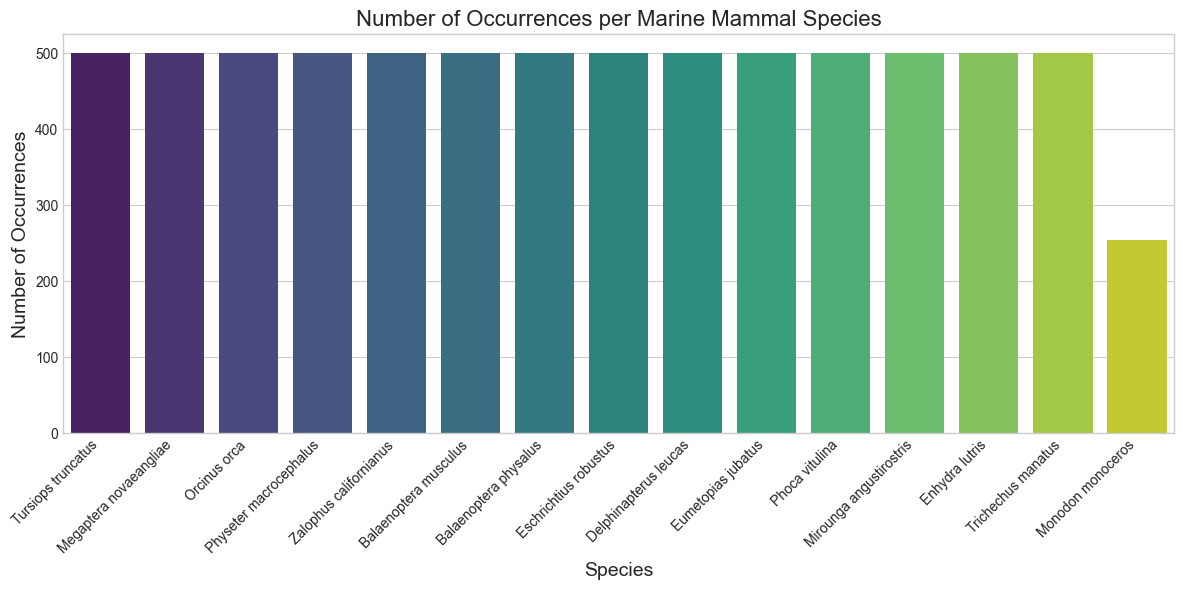

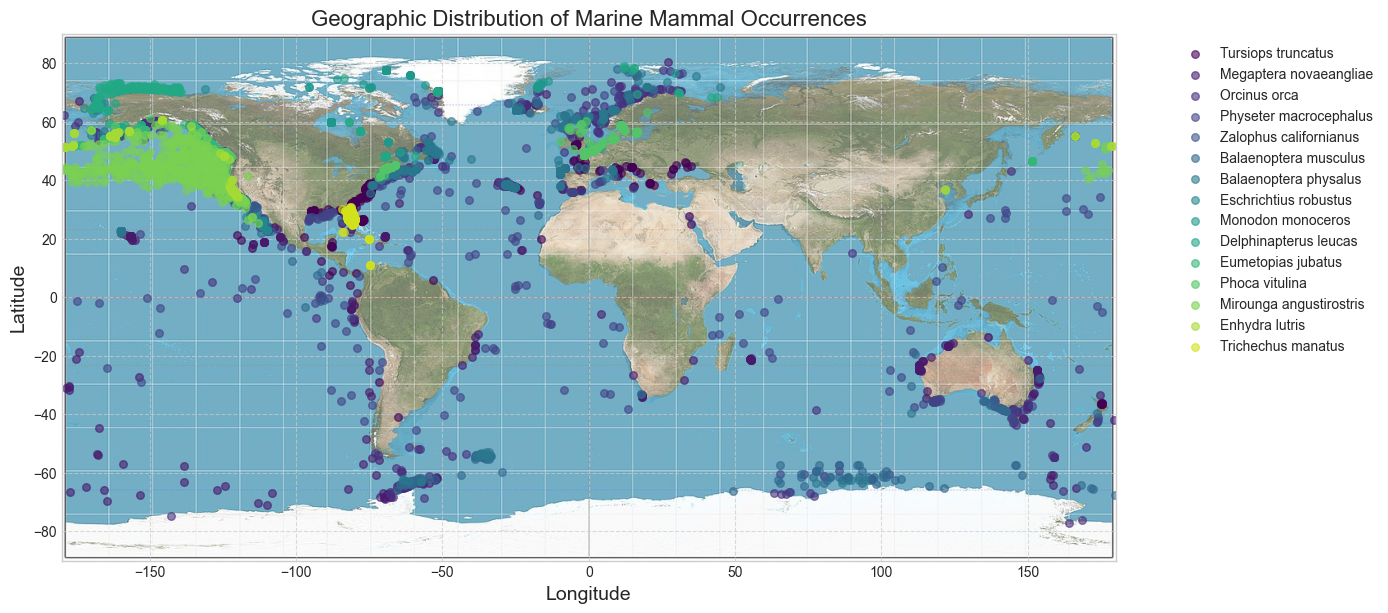

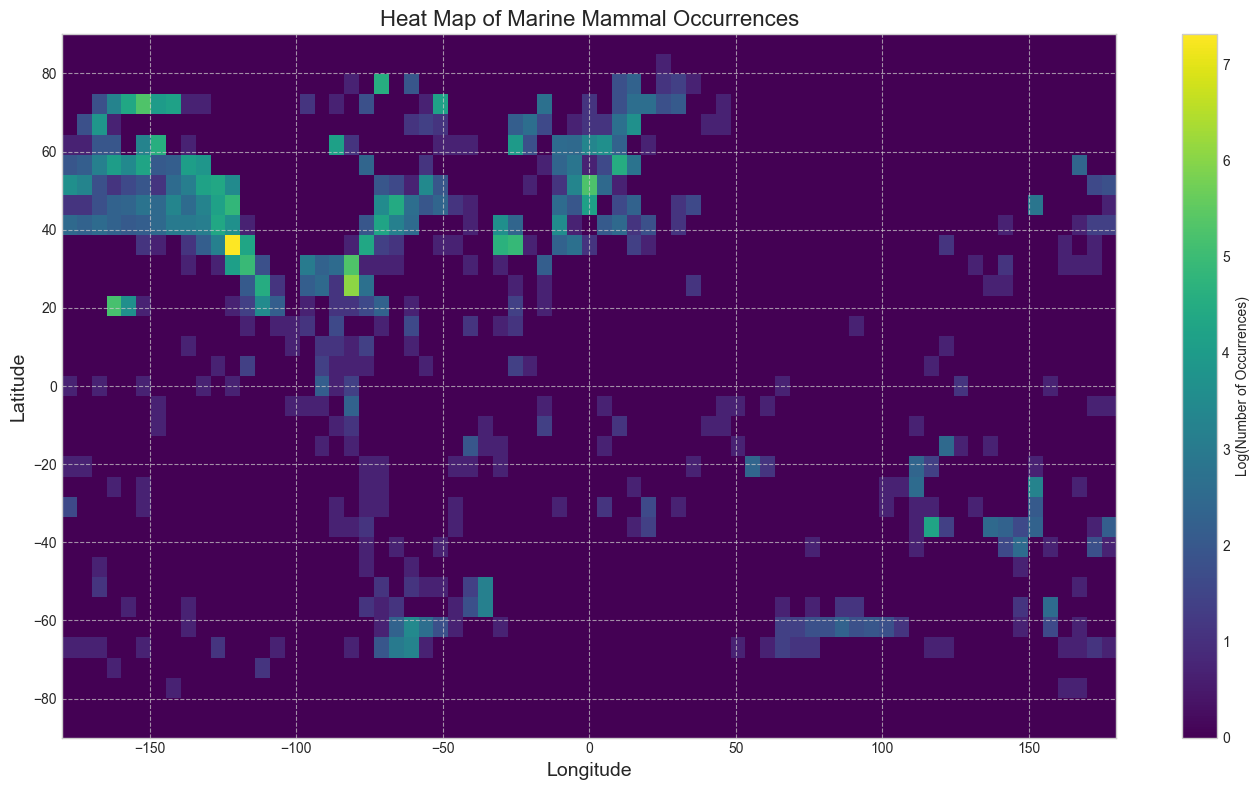

<Figure size 1200x600 with 0 Axes>

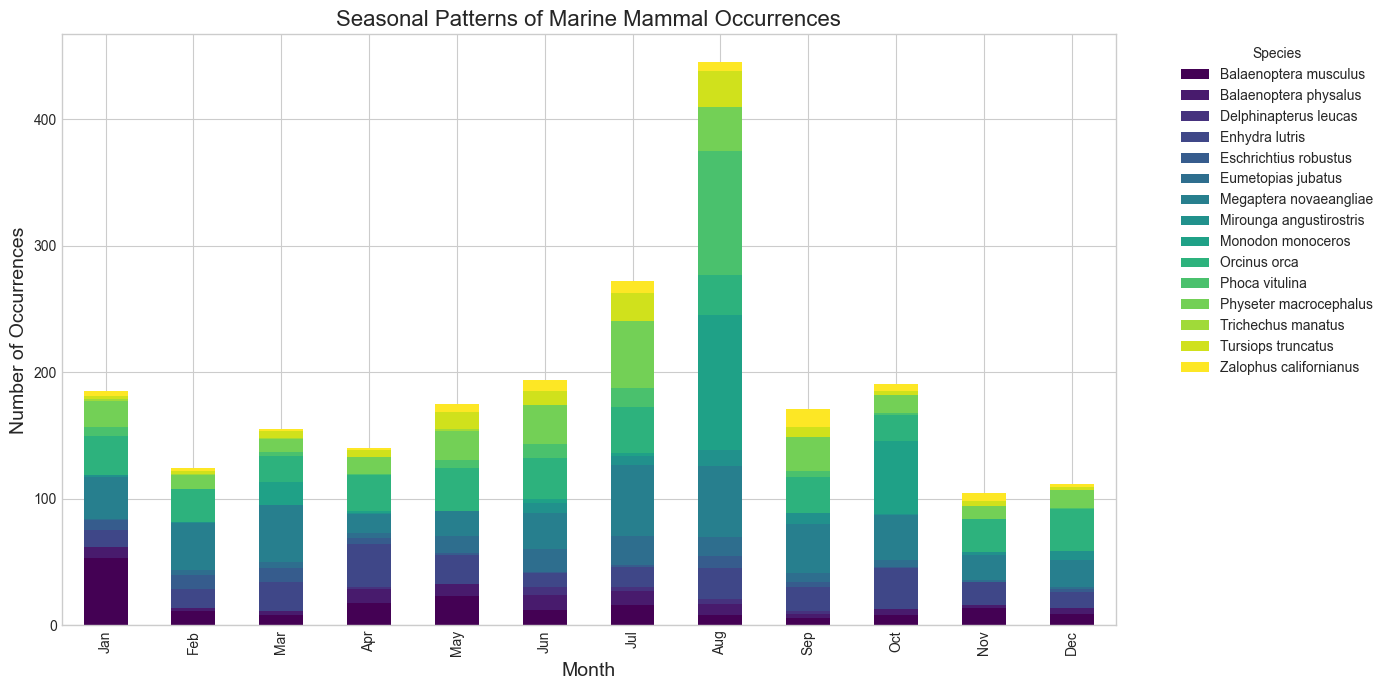

In [ ]:
def initial_analysis():
    species_counts = all_occurrences['species_name'].value_counts()
    plot_species_counts(species_counts)

    valid_coords = all_occurrences.dropna(subset=['decimalLongitude', 'decimalLatitude'])
    species_colors = {species: plt.cm.viridis(i / len(marine_mammals)) for i, species in enumerate(valid_coords['species_name'].unique())}
    plot_geographic_distribution(valid_coords, species_colors)

    plot_heatmap(valid_coords)
    plot_seasonal_patterns(all_occurrences)

initial_analysis()


In [ ]:
def predict_vessel_collision_risk(vessel_routes_df, all_occurrences):
    """
    Predict the collision risk between vessels and marine mammals based on proximity,
    seasonal factors, and species density within a search radius.
    """
    valid_coords = all_occurrences.dropna(subset=['decimalLongitude', 'decimalLatitude']).copy()
    risk_results = pd.DataFrame(columns=[
        'vessel_id', 'timestamp', 'longitude', 'latitude', 
        'collision_risk_score', 'nearby_species', 'distance_km', 'season_factor'
    ])

    search_radius_km = 10.0  # Radius within which to search for nearby animals
    EARTH_RADIUS = 6371.0  # Earth's radius in kilometers






    def haversine_distance(lat1, lon1, lat2, lon2):
        """
        Calculate the great-circle distance between two points on the Earth's surface.
        """
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(a))
        return EARTH_RADIUS * c





    # Calculate seasonal factors based on monthly occurrence data
    """
    If the 'month' column exists in the data, calculate seasonal factors based on the 
    total number of occurrences per month. Otherwise, use default seasonal factors.
    """
    if 'month' in valid_coords.columns:
        monthly_counts = valid_coords.groupby(['month', 'species_name']).size().unstack(fill_value=0)
        total_monthly = monthly_counts.sum(axis=1)
        seasonal_factors = total_monthly / total_monthly.max()
    else:
        seasonal_factors = pd.Series({
            1: 0.5, 2: 0.6, 3: 0.7, 4: 0.8, 5: 0.9, 6: 1.0,
            7: 1.0, 8: 0.9, 9: 0.8, 10: 0.7, 11: 0.6, 12: 0.5
        })





    # Iterate through each vessel route to calculate collision risk
    """
    For each vessel route, calculate the collision risk based on:
    - Distance factor: Proximity of the vessel to nearby animals.
    - Species count factor: Number of species within the search radius.
    - Seasonal factor: Adjust risk based on the time of year.
    """
    for _, vessel_row in vessel_routes_df.iterrows():
        vessel_id = vessel_row['vessel_id']
        vessel_lon = vessel_row['longitude']
        vessel_lat = vessel_row['latitude']
        timestamp = vessel_row['timestamp']

        try:                                                            
            vessel_month = pd.to_datetime(timestamp).month
            season_factor = seasonal_factors.get(vessel_month, 0.75)       
        except:
            season_factor = 0.75

        nearby_animals = []
        min_distance = float('inf')

        for _, animal_row in valid_coords.iterrows():
            animal_lon = animal_row['decimalLongitude']
            animal_lat = animal_row['decimalLatitude']
            species = animal_row['species_name']
            distance = haversine_distance(vessel_lat, vessel_lon, animal_lat, animal_lon)

            if distance <= search_radius_km:
                nearby_animals.append(species)
                min_distance = min(min_distance, distance)

        if nearby_animals:
            # Calculate risk score based on distance, species count, and seasonal factors
            """
            Risk score calculation:
            - Distance factor: Higher risk for closer proximity to animals.
            - Species count factor: Higher risk for more species in the area.
            - Seasonal factor: Adjust risk based on seasonal animal activity.
            """
            distance_factor = 1.0 - (min_distance / search_radius_km)
            species_count_factor = min(1.0, len(nearby_animals) / 5.0)
            risk_score = 100 * (0.6 * distance_factor + 0.3 * species_count_factor + 0.1 * season_factor)

            risk_results = pd.concat([risk_results, pd.DataFrame([{
                'vessel_id': vessel_id,
                'timestamp': timestamp,
                'longitude': vessel_lon,
                'latitude': vessel_lat,
                'collision_risk_score': round(risk_score, 1),
                'nearby_species': ', '.join(set(nearby_animals)),
                'distance_km': round(min_distance, 2),
                'season_factor': round(season_factor, 2)
            }])], ignore_index=True)







    # Assign risk levels based on the calculated risk score
    """
    Categorize risk levels based on the collision risk score:
    - Low: 0-25
    - Moderate: 26-50
    - High: 51-75
    - Very High: 76-100
    """
    risk_results['risk_level'] = pd.cut(
        risk_results['collision_risk_score'],
        bins=[0, 25, 50, 75, 100],
        labels=['Low', 'Moderate', 'High', 'Very High']
    )

    return risk_results


In [ ]:
def visualize_collision_risk(risk_results, vessel_routes_df, all_occurrences):
    """
    Basic Flow:
    - Plot World map background
    - Plot marine mammal occurrences
    - Plot possible risk-collision points
    - Highlight clusters of collision points
    """
    print("Generating collision risk visualization...")

    plt.figure(figsize=(14, 8))

    img_extent = (-180, 180, -90, 90)
    url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/8/83/Equirectangular_projection_SW.jpg/1280px-Equirectangular_projection_SW.jpg'
    world_map = np.array(PIL.Image.open(urllib.request.urlopen(url)))   
    plt.imshow(world_map, extent=img_extent, alpha=0.7)






    # Plot Marine Mammal Occurrences
    valid_coords = all_occurrences.dropna(subset=['decimalLongitude', 'decimalLatitude'])
    if not valid_coords.empty:
        plt.scatter(
            valid_coords['decimalLongitude'], 
            valid_coords['decimalLatitude'],
            c='blue',
            alpha=0.6,
            s=30,
            label='Marine Mammal Occurrences'
        )





    # Plot the possible collision points
    if not risk_results.empty:                     
        plt.scatter(
            risk_results['longitude'], 
            risk_results['latitude'],
            c='orange',
            marker='*',
            s=80,
            alpha=0.8,
            label='Possible Collison Points'
        )







        # Highlighting with a red rectangle
        if len(risk_results) > 1:
            coords = risk_results[['longitude', 'latitude']].values
            clustering = DBSCAN(eps=0.5, min_samples=1).fit(coords)
            risk_results['cluster'] = clustering.labels_

            for cluster_id in set(clustering.labels_):
                cluster_points = risk_results[risk_results['cluster'] == cluster_id]
                min_lon = cluster_points['longitude'].min() - 2
                max_lon = cluster_points['longitude'].max() + 2
                min_lat = cluster_points['latitude'].min() - 2
                max_lat = cluster_points['latitude'].max() + 2
                rect = Rectangle((min_lon, min_lat), max_lon-min_lon, max_lat-min_lat,
                                 linewidth=2, edgecolor='red', facecolor='none', alpha=0.7, zorder=10)  
                plt.gca().add_patch(rect)
        else:
            min_lon = risk_results['longitude'].min() - 2
            max_lon = risk_results['longitude'].max() + 2
            min_lat = risk_results['latitude'].min() - 2
            max_lat = risk_results['latitude'].max() + 2
            rect = Rectangle((min_lon, min_lat), max_lon-min_lon, max_lat-min_lat,
                             linewidth=2, edgecolor='red', facecolor='none', zorder=10)  
            plt.gca().add_patch(rect)
    else:
        min_lon = vessel_routes_df['longitude'].min() - 2
        max_lon = vessel_routes_df['longitude'].max() + 2
        min_lat = vessel_routes_df['latitude'].min() - 2
        max_lat = vessel_routes_df['latitude'].max() + 2
        rect = Rectangle((min_lon, min_lat), max_lon-min_lon, max_lat-min_lat,
                         linewidth=2, edgecolor='blue', facecolor='none', zorder=10)  
        plt.gca().add_patch(rect)
    







    # Main Plot
    plt.title('Marine Collision Risk Study Area', fontsize=16)
    plt.xlabel('Longitude', fontsize=14)
    plt.ylabel('Latitude', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()












Collision Risk Assessment:
  vessel_id           timestamp  collision_risk_score risk_level  nearby_species
0      V001 2023-01-01 01:00:00                  22.0        Low    Orcinus orca
1      V007 2023-01-01 13:00:00                  41.3   Moderate  Phoca vitulina
Generating collision risk visualization...


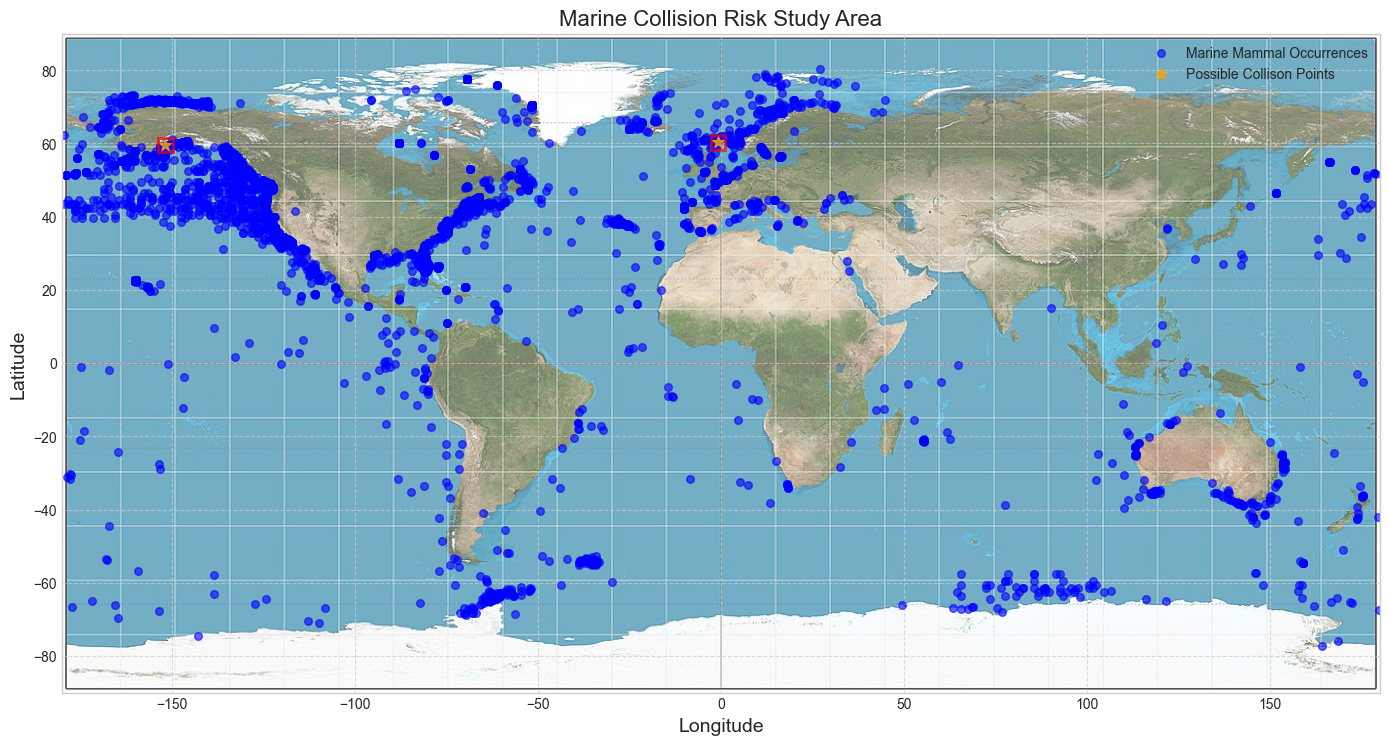


Total risk locations: 2
Average risk score: 31.6


In [ ]:
def main(all_occurrences):
    
    # Example vessel routes data
    vessel_routes = pd.DataFrame({
        'vessel_id': ['V001', 'V001', 'V002', 'V002', 'V003', 'V003', 'V004', 'V004', 'V005', 'V005', 'V006', 'V006',
                      'V007', 'V007', 'V008', 'V008', 'V009', 'V009', 'V010', 'V010'],
        'timestamp': pd.date_range(start='2023-01-01', periods=20, freq='H'),
        'longitude': [-151.5, -151.8, -152.0, -152.3, -153.2, -153.5, -154.0, -154.3, -155.1, -155.4, -156.3, -156.6,
                      -0.5, -0.8, -1.0, -1.3, -2.0, -2.3, -3.0, -3.3],
        'latitude': [59.8, 59.6, 59.5, 59.3, 59.2, 59.0, 58.9, 58.7, 58.6, 58.4, 58.3, 58.1,
                     60.1, 60.3, 60.5, 60.7, 60.9, 61.1, 61.3, 61.5],
        'course': [270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325,
                   0, 5, 10, 15, 20, 25, 30, 35]
    })

    risk_results = predict_vessel_collision_risk(vessel_routes, all_occurrences)
    
   
    if risk_results.empty:
        print("No collision risks identified.")
    else:
        print("\nCollision Risk Assessment:")
        print(risk_results[['vessel_id', 'timestamp', 'collision_risk_score', 'risk_level', 'nearby_species']])
        
        visualize_collision_risk(risk_results, vessel_routes, all_occurrences)
        
        risk_count = len(risk_results)  
        print(f"\nTotal risk locations: {risk_count}")
        print(f"Average risk score: {risk_results['collision_risk_score'].mean():.1f}")

if __name__ == "__main__":
    main(all_occurrences)